In [1]:
# illustrative example of use VeraRubin 

## Injection procedure example 

> Version: 1.0
> 
> Container Size: Large

> Description:  In this notebook, we present an illustrative example of using the injection functions from the VeraRubin package.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Complementary info
! echo $IMAGE_DESCRIPTION
! eups list -s | grep lsst_distrib

Release r29.2.0 (RSP Build 2648)
lsst_distrib          gc675d380bf+f75de59d28 	current v29_2_0 v29_2_0_rc1 setup


In [4]:
# Loading modules
import numpy as np
import VeraRubin as vr
import astropy.units as u
import matplotlib.pyplot as plt

from astropy.io import fits
#from astropy.wcs import WCS
#from astropy.coordinates import SkyCoord

#### Making a butler instance

In [5]:
butler = vr.ExpButler(info=False).butler  # using default adress
REMOTE_REPO = vr.get_butler_location(butler)

In [6]:
# Defining the sky coordinates and the selected band
ra_deg, dec_deg = (53.2, -27.8)  # RA, Dec
loc_data = (ra_deg, dec_deg)
band = 'u'

# Opening the FITS file
stamp_paths = ['stamp/PGC_038749_I_g_bbl2011_original.fits']

# Defining the properties of the stamp
mags = [14.8]  # Magnitude used to inject the stamp

# Sky position of the injection
ra_list, dec_list = [ra_deg], [dec_deg]

In [10]:
injected_exposure = vr.main_inject_stamp(
        REPO=REMOTE_REPO,
        collections="LSSTComCam/DP1",
        loc=loc_data,
        band=band,
        stamp_paths=stamp_paths,
        mags=mags,
        ra_list=ra_list,
        dec_list=dec_list,
        sky_coordinates=True,
        use_patch_area=False,
        detectors=None,
        timespan=None,
        visit_ids= None, # [2024113000172], 
        num_select=3,  # Number of selected visits
        min_sep=0.0005,
        separation_spherical=True,
        keep_size=False,
        interp_order=3,
        update_wcs=False,
        info_save_path='test/save_test',
        rot_name_save="test/stamp_rotated",
        remove_rotated_stamps=True,
        info=True)

[INFO] Loading the butler...
[INFO] Injection on sky coordinates: RA=53.2, Dec=-27.8
[INFO] Found 31 visits for band=u
END: Collect visit exposures and getWcs info
Execution time: 66.373 seconds
[INFO] Using 3 visits after sorting and selection.
[INFO] Computed 3 rotation angles.


[INFO] Injection complete.


#### Some plots

In [11]:
# Loading info
info_txt_path = 'test/save_test.txt'
with open(info_txt_path, "r") as f:
    info = json.load(f)

In [12]:
# Info
visit_name = info['Parameters']['visit_name']
points = info['Parameters']['points']
visits = info['data_Id']

[INFO] Converted LSST SkyWcs -> Astropy WCS


/home/arestrada88/Alma_proyect/VeraRubin/plot/exposure_plot.py:223: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


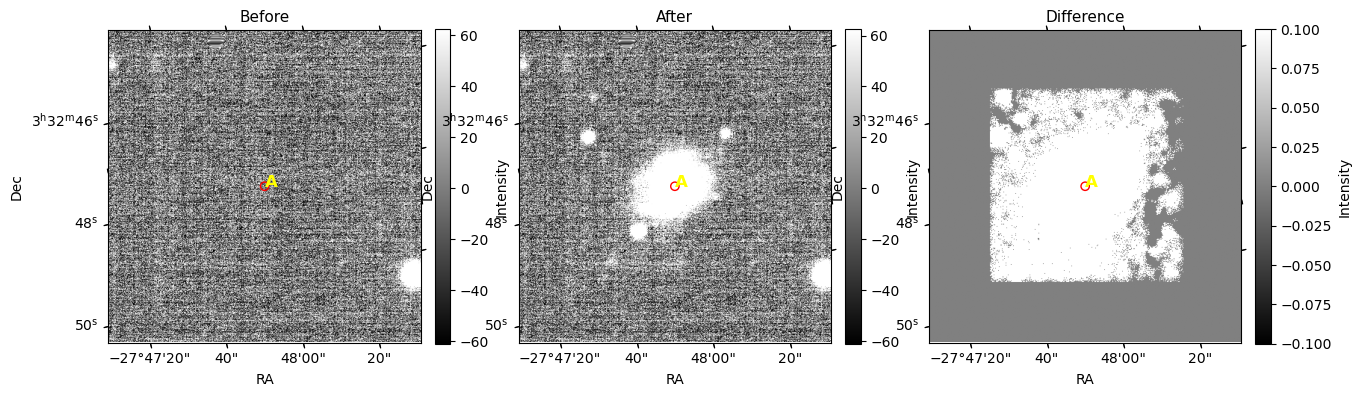

[INFO] Converted LSST SkyWcs -> Astropy WCS


/home/arestrada88/Alma_proyect/VeraRubin/plot/exposure_plot.py:223: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


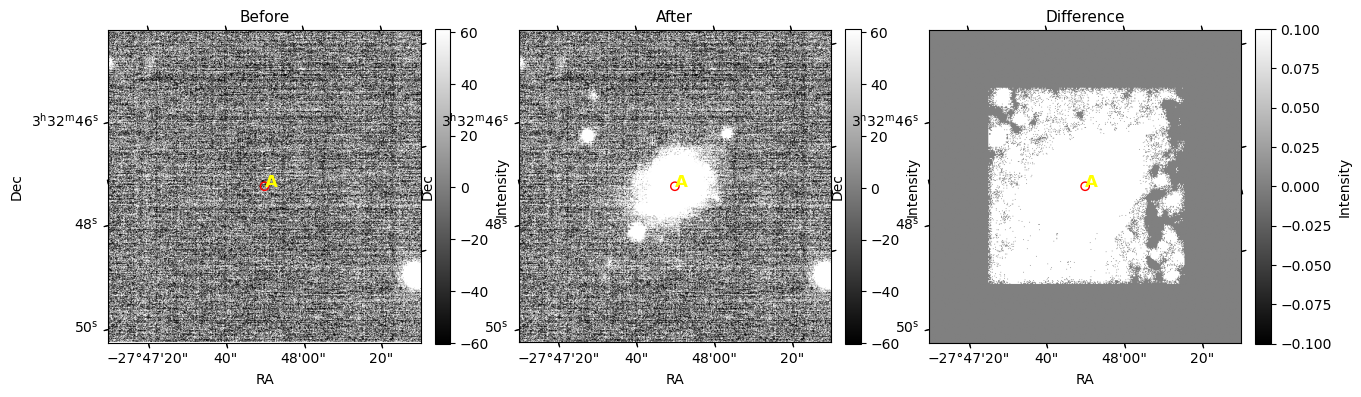

[INFO] Converted LSST SkyWcs -> Astropy WCS


/home/arestrada88/Alma_proyect/VeraRubin/plot/exposure_plot.py:223: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


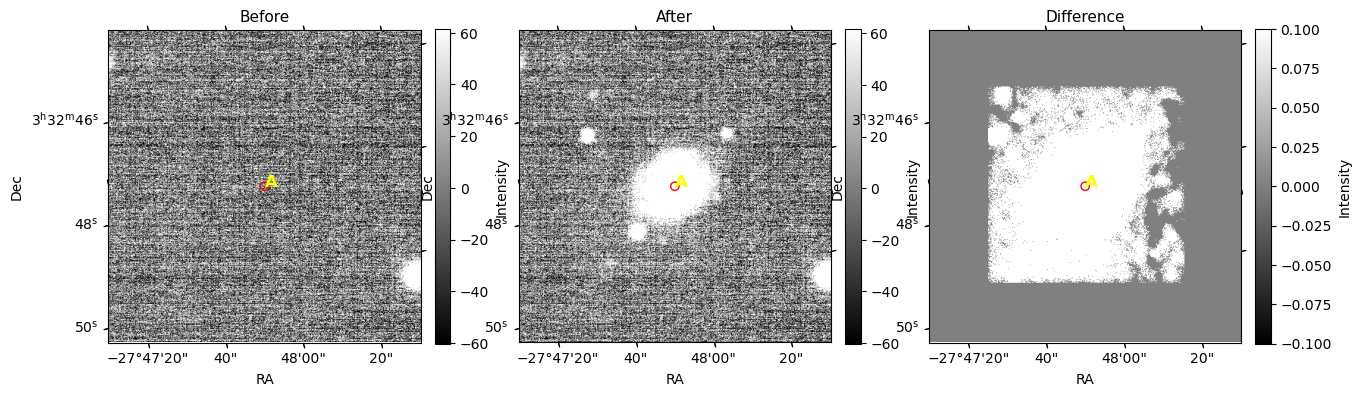

In [13]:
for i in range(len(visits)):
    before = butler.get(visit_name, dataId=visits[str(i)]['dataId'])
    after = injected_exposure[i]
    vr.injection_steps(before, after, points,
                       diference=True,
                       cutout_radius_arcsec=10,  # arcsec 
                       grid=False, percentiles=[5, 95])

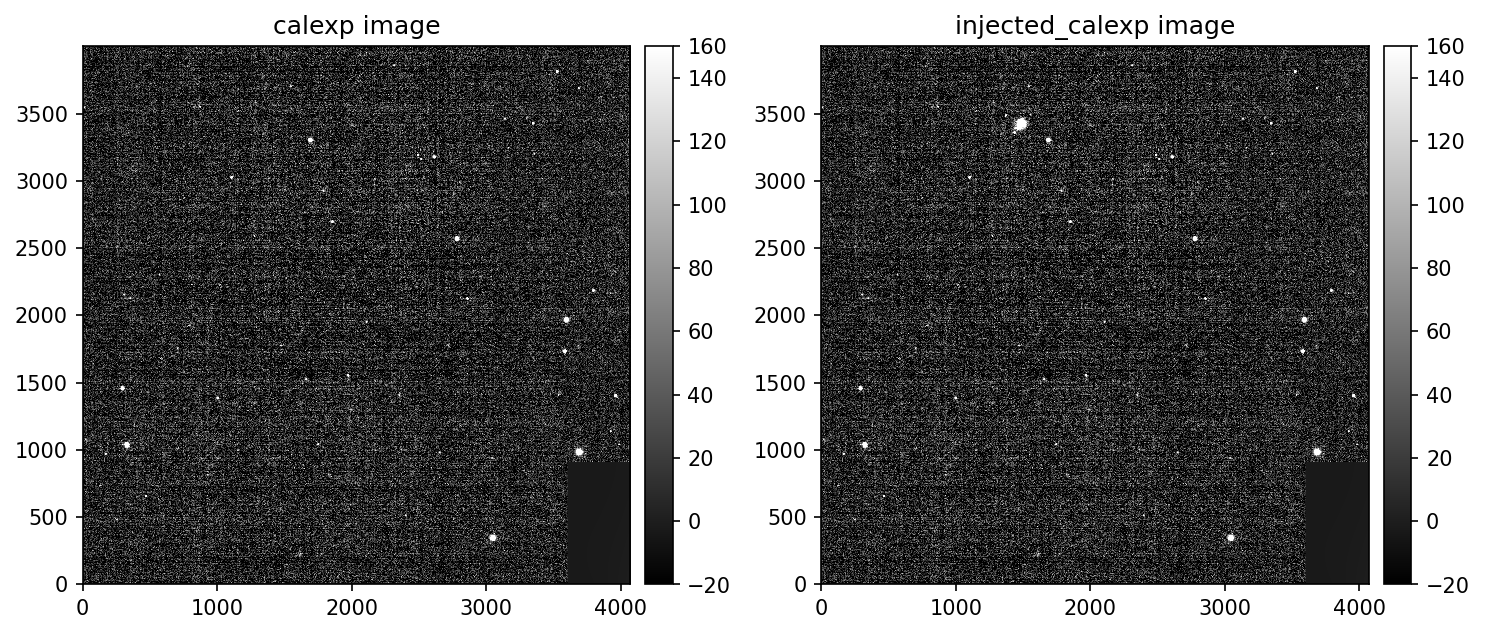

In [14]:
# Other option
import lsst.afw.display as afwDisplay
afwDisplay.setDefaultBackend("matplotlib")

num = 2
visit_img = butler.get('visit_image', dataId=visits[str(num)]['dataId'])
plot_injected_img = injected_exposure[num].clone()

fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=150)

plt.sca(ax[0])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(visit_img.image)
plt.title('calexp image')

plt.sca(ax[1])
display1 = afwDisplay.Display(frame=fig)
# display1.scale('linear', 'zscale')
display1.scale('linear', min=-20, max=150)
display1.mtv(plot_injected_img.image)
# To zoom on the PGC 038749 stamp:
# display1.mtv(plot_injected_img.image[1700:2200, 1950:2450])
plt.title('injected_calexp image')

plt.tight_layout()
plt.show()

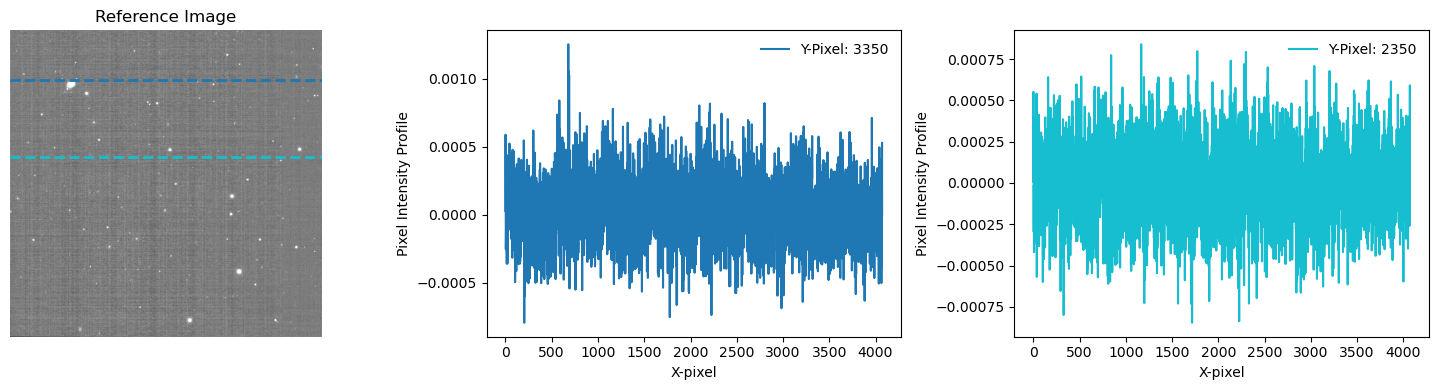

In [15]:
# Pixel intensity at some y_pixel position

image_array = injected_exposure[0].image.getArray()
y_positions_pixel = [3350, 2350]
vr.pixel_intensity([image_array],
                   y_positions_pixel,
                   image_ref=True,
                   save_path=None)